# Week 5 Assignment: Deep Learning & Global Models
**DSE6230: Forecasting Methods and Applications**

In this assignment, you will explore **Global Models** using `neuralforecast`, then compare them against **zero-shot foundation models** that require no training at all.

1. **Data Prep**: Loading Panel Data (Long format).
2. **Model Training**: MLP / LSTM / NHITS / N-BEATS (local and global models).
3. **Zero-Shot Forecasting**: TimeGPT and/or Chronos.
4. **Synthesis**: Trained vs. zero-shot tradeoffs.

In [5]:
!pip install pandas numpy matplotlib neuralforecast datasetsforecast nixtla chronos-forecasting torch statsforecast pyreadr

In [4]:
import time, logging, warnings, urllib.request
import pyreadr
from functools import partial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from neuralforecast import NeuralForecast
from neuralforecast.utils import AirPassengersPanel
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, SeasonalNaive
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, smape, mase

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

# Scoring template for the exercises
def score(fcst_df, actual_df, train_df, models, season):
    merged = actual_df.merge(fcst_df, on=["unique_id", "ds"], how="inner")
    ev = evaluate(
        merged,
        metrics=[mae, rmse, smape, partial(mase, seasonality=season)],
        train_df=train_df,
        models=models,
        agg_fn="mean",
    )
    return ev.set_index("metric").T.round(3)

## Part 1: The Global Model
Use the `AirPassengers` panel data below, or an `M4` subset (10 series) if you prefer.

In [6]:
# Raw data: long-format panel with columns unique_id, ds, y
df = AirPassengersPanel.copy()
horizon = 12

### Exercise 1.1: Load Data
Load a dataset containing at least 5 different time series. Ensure columns are `unique_id`, `ds`, `y`.

In [7]:
# Your Code Here
M4_URL = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset"
N_SERIES = 10
MAX_TRAIN_LEN = 240 # Most recent 20 years

import io

def read_first_rows(url, n):
    # collect only a selection of the M4 rows, since there's an incredible amount
    # of entries otherwise.
    with urllib.request.urlopen(url) as r:
        lines = [r.readline() for _ in range(n + 1)]
    return pd.read_csv(io.BytesIO(b"".join(lines)))

# Get the train & test split
train_wide = read_first_rows(f"{M4_URL}/Train/Monthly-train.csv", N_SERIES)
test_wide = read_first_rows(f"{M4_URL}/Test/Monthly-test.csv", N_SERIES)

# Convert wide to long
def wide_to_long(wide):
    long = wide.melt(id_vars="V1", var_name="t", value_name="y").dropna()
    long["t"] = long["t"].str[1:].astype(int)
    return long.rename(columns={"V1": "unique_id"}).sort_values(["unique_id", "t"])

# Fix the sets
train_long = wide_to_long(train_wide).groupby("unique_id").tail(MAX_TRAIN_LEN)
test_long = wide_to_long(test_wide).groupby("unique_id").head(horizon)

# End of training
TRAIN_END = pd.Timestamp("2015-12-01")

# Adding the dates to fit the columns format
def add_dates(long, end):
    out = []
    for uid, g in long.groupby("unique_id", sort=False):
        g = g.copy()
        g["ds"] = pd.date_range(end=end, periods=len(g), freq="MS")
        out.append(g)
    return pd.concat(out)[["unique_id", "ds", "y"]].reset_index(drop=True)

# Final data frame for working with
train_df = add_dates(train_long, TRAIN_END)
test_df = add_dates(test_long, TRAIN_END + pd.DateOffset(months=horizon))
df = pd.concat([train_df, test_df]).sort_values(["unique_id", "ds"]).reset_index(drop=True)

# Assert all are correct
assert list(df.columns) == ["unique_id", "ds", "y"]
print(f"{df['unique_id'].nunique()} series | train rows: {len(train_df)} | test rows: {len(test_df)}")
print(train_df.groupby("unique_id")["y"].agg(["count", "mean", "min", "max"]).round(0)) # Print our 5 time series
df.head()

10 series | train rows: 1858 | test rows: 120
           count    mean     min      max
unique_id                                
M1           240  6102.0  2690.0  13490.0
M10          240  7912.0  6630.0   9660.0
M2           240  2235.0  1240.0   3740.0
M3           240  9339.0  6118.0  13395.0
M4            82  6866.0  6567.0   7264.0
M5           112  4371.0  4120.0   4560.0
M6           240  9633.0  7700.0  12300.0
M7           112  1072.0   865.0   1294.0
M8           112  1200.0   796.0   1596.0
M9           240  6508.0  4500.0   8770.0


,unique_id,ds,y
0,M1,1996-01-01,6090.0
1,M1,1996-02-01,7000.0
2,M1,1996-03-01,5370.0
3,M1,1996-04-01,5230.0
4,M1,1996-05-01,5140.0


### Exercise 1.2: Train NHITS
Initialize and fit an `NHITS` model with `input_size=2*horizon` and `h=horizon`.

In [8]:
from neuralforecast.models import NHITS
from neuralforecast import NeuralForecast
# Your code

QUIET = dict(enable_progress_bar=False, enable_model_summary=False, logger=False)
SEED = 42

# Establish the NHITS parameters
nhits = NHITS(
    h=horizon,
    input_size=2 * horizon,
    max_steps=500,
    scaler_type="robust",
    random_seed=SEED,
    **QUIET,
)
nf = NeuralForecast(models=[nhits], freq="MS")

# Time it and display for Exercise 1.3
t0 = time.perf_counter()
nf.fit(df=train_df)
nhits_fit_secs = time.perf_counter() - t0
nhits_fcst = nf.predict().reset_index(drop=True)
nhits_total_secs = time.perf_counter() - t0
print(f"NHITS training + prediction: {nhits_total_secs:.1f} s")
nhits_fcst.head()

INFO:lightning_fabric.utilities.seed:Seed set to 42


NHITS training + prediction: 7.3 s


,unique_id,ds,NHITS
0,M1,2016-01-01,7900.226562
1,M1,2016-02-01,7306.969727
2,M1,2016-03-01,6220.273438
3,M1,2016-04-01,5838.415039
4,M1,2016-05-01,5631.041992


### Exercise 1.3: Compare to ARIMA
Why might NHITS outperform (or underperform) ARIMA on this specific dataset? Discuss "Transfer Learning" (information sharing across series).

In [9]:
# PER - SERIES MAE
# Create the model itself
sf = StatsForecast(models=[AutoARIMA(season_length=12), SeasonalNaive(season_length=12)], freq="MS", n_jobs=-1)
t0 = time.perf_counter()
stat_fcst = sf.forecast(df=train_df, h=horizon).reset_index(drop=True)
arima_secs = time.perf_counter() - t0
print(f"AutoARIMA + SeasonalNaive for 10 series: {arima_secs:.1f} s")

# Collect the information
part1_fcst = nhits_fcst.merge(stat_fcst, on=["unique_id", "ds"])
part1_models = ["NHITS", "AutoARIMA", "SeasonalNaive"]
part1_scores = score(part1_fcst, test_df, train_df, part1_models, season=12)
part1_scores

# Merge frames together for one cohesive output
per_series = test_df.merge(part1_fcst, on=["unique_id", "ds"])
per_series_mae = (
    per_series.groupby("unique_id")
    .apply(lambda g: pd.Series({m: np.mean(np.abs(g["y"] - g[m])) for m in part1_models}))
    .round(1)
)
per_series_mae["best"] = per_series_mae[part1_models].idxmin(axis=1)
print(per_series_mae)
print("\nWins per model:", per_series_mae["best"].value_counts().to_dict())

AutoARIMA + SeasonalNaive for 10 series: 39.5 s
           NHITS  AutoARIMA  SeasonalNaive       best
unique_id                                            
M1         997.4      682.4          824.2  AutoARIMA
M10        392.4      449.5         1019.2      NHITS
M2         480.5      262.0          346.7  AutoARIMA
M3         618.4      170.5          591.1  AutoARIMA
M4          92.3      110.9          178.8      NHITS
M5          67.3       60.0           87.5  AutoARIMA
M6         690.0      548.0         1225.0  AutoARIMA
M7          97.8      110.1          195.5      NHITS
M8          90.5       74.1          210.8  AutoARIMA
M9         175.0      136.5          148.3  AutoARIMA

Wins per model: {'AutoARIMA': 7, 'NHITS': 3}


In [10]:
"""
NHITS is, importantly, a global model. Weights used with NHITS are trained using all 10 series at once, done across hundreds of training windows. As each window is scaled,
the network in its development learns shapes (things like seasonality and trends) that are shared across all of the series, and thus can apply what it learns from one series
to another in its predictions. That is the "Transfer Learning" property that makes the model excel in many cases against local models. That being said, against ARIMA, the
model underperforms in comparison when handling small data sets. Given our data set's small size, alongside the highly varied nature of the competition data set, does not
lend itself well to a high depth model like NHITS. Instead, something like ARIMA is better suited to handling these small form sets, as its parameter adaptability compensates
for the more stark changes.
"""

' \nNHITS is, importantly, a global model. Weights used with NHITS are trained using all 10 series at once, done across hundreds of training windows. As each window is scaled, \nthe network in its development learns shapes (things like seasonality and trends) that are shared across all of the series, and thus can apply what it learns from one series\nto another in its predictions. That is the "Transfer Learning" property that makes the model excel in many cases against local models. That being said, against ARIMA, the \nmodel underperforms in comparison when handling small data sets. Given our data set\'s small size, alongside the highly varied nature of the competition data set, does not \nlend itself well to a high depth model like NHITS. Instead, something like ARIMA is better suited to handling these small form sets, as its parameter adaptability compensates\nfor the more stark changes.\n'

### Exercise 1.4: The Gasoline Series (FPP Ch. 14, Q2)
Consider the weekly data on US finished motor gasoline products supplied (millions of barrels per day), series `us_gasoline`.

1. Use the `MLP` model to forecast the next 13 weeks of data.
2. Repeat using the `AutoMLP` and `AutoNHITS` models from `NeuralForecast`.
3. Compare the accuracy of the three models.

In [11]:
from neuralforecast.models import MLP
from neuralforecast.auto import AutoMLP, AutoNHITS
from neuralforecast import NeuralForecast

# Your code
from ray import tune
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

# us_gasoline (fpp3): weekly US finished motor gasoline product supplied, million barrels/day.
GAS_URL = "https://raw.githubusercontent.com/robjhyndman/fpp3package/master/data/us_gasoline.rda"
urllib.request.urlretrieve(GAS_URL, "us_gasoline.rda")
gas = pyreadr.read_r("us_gasoline.rda")["us_gasoline"]

# Data frame needs to fix the date-time objects
gas_df = pd.DataFrame({
    "unique_id": "us_gasoline",
    "ds": pd.to_datetime(gas["Week"], unit="D"),
    "y": gas["Barrels"].astype(float),
})
GAS_FREQ, GAS_H = "W-MON", 13
assert gas_df["ds"].diff().dropna().eq(pd.Timedelta(days=7)).all()

# Hold out the final 13 weeks to measure accuracy
gas_train = gas_df.iloc[:-GAS_H].reset_index(drop=True)
gas_test = gas_df.iloc[-GAS_H:].reset_index(drop=True)
print(f"{len(gas_df)} weeks: {gas_df.ds.min().date()} to {gas_df.ds.max().date()}")
print(f"Training through {gas_train.ds.max().date()}, testing {gas_test.ds.min().date()} to {gas_test.ds.max().date()}")

1355 weeks: 1991-02-04 to 2017-01-16
Training through 2016-10-17, testing 2016-10-24 to 2017-01-16


In [12]:
# #1 -> MLP
mlp = MLP(h=GAS_H, input_size=104, num_layers=2, hidden_size=256,
          max_steps=500, scaler_type="robust", random_seed=SEED, **QUIET)
t0 = time.perf_counter()
nf_mlp = NeuralForecast(models=[mlp], freq=GAS_FREQ)
nf_mlp.fit(df=gas_train)
gas_mlp = nf_mlp.predict().reset_index(drop=True)
print(f"MLP: {time.perf_counter() - t0:.1f} s")


INFO:lightning_fabric.utilities.seed:Seed set to 42


MLP: 4.6 s


In [13]:
def capped_config(auto_cls, h, **overrides):
    # Configured space for the models using Optuna
    cfg = auto_cls.get_default_config(h=h, backend="ray")
    cfg.update(max_steps=tune.choice([300, 500]), random_seed=SEED, **QUIET, **overrides)
    return auto_cls._ray_config_to_optuna(cfg)

# Create both of the auto models
auto_models = [
    AutoMLP(h=GAS_H, config=capped_config(AutoMLP, GAS_H), backend="optuna", num_samples=10,
            search_alg=optuna.samplers.TPESampler(seed=SEED)),
    AutoNHITS(h=GAS_H, config=capped_config(AutoNHITS, GAS_H), backend="optuna", num_samples=10,
              search_alg=optuna.samplers.TPESampler(seed=SEED)),
]

# Record the time and log
t0 = time.perf_counter()
nf_auto = NeuralForecast(models=auto_models, freq=GAS_FREQ)
nf_auto.fit(df=gas_train, val_size=52)
gas_auto = nf_auto.predict().reset_index(drop=True)
print(f"AutoMLP + AutoNHITS search: {time.perf_counter() - t0:.1f} s")

# Comparions of models
for m in nf_auto.models:
    best = m.results.best_trial
    print(f"{type(m).__name__} best validation MAE {best.value:.3f} with",
          {k: v for k, v in best.params.items() if k in ("input_size", "learning_rate", "num_layers",
                                                          "hidden_size", "n_freq_downsample", "max_steps")})

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightni

AutoMLP + AutoNHITS search: 100.3 s
AutoMLP best validation MAE 0.248 with {'hidden_size': 512, 'num_layers': 6, 'learning_rate': 0.000258560889073134, 'max_steps': 300, 'input_size': 65}
AutoNHITS best validation MAE 0.233 with {'n_freq_downsample': [24, 12, 1], 'learning_rate': 0.0011895896737553553, 'max_steps': 300, 'input_size': 39}


In [14]:
# Overall comparison
gas_snaive = StatsForecast(models=[SeasonalNaive(season_length=52)], freq=GAS_FREQ).forecast(df=gas_train, h=GAS_H)
gas_fcst = (gas_mlp.merge(gas_auto, on=["unique_id", "ds"])
                   .merge(gas_snaive.reset_index(drop=True), on=["unique_id", "ds"]))
gas_models = ["MLP", "AutoMLP", "AutoNHITS", "SeasonalNaive"]
gas_scores = score(gas_fcst, gas_test, gas_train, gas_models, season=52)
gas_scores.sort_values("mae")

# ANALYSIS
# Overall, the best accuracy was hdad by our AutoMLP model, with a close follow-up in MAE from the SeasonalNaive, then AutoNHITS, and in last the standard MLP.
# In comparison to the naive model, most of our models were failures, with a notably higher MAE, RMSE, SMAPE and MASE across the board, with only AutoMLP beating
# out SeasonalNaive. With only one series to train on, cross-series learning is not feasible, and so it's difficult for a more complex network to rise above
# on otherwise simplistic data that the naive model can already predict on decently well.

metric,mae,rmse,smape,mase
AutoMLP,0.298,0.372,0.017,1.034
SeasonalNaive,0.326,0.454,0.019,1.134
AutoNHITS,0.417,0.520,0.024,1.447
MLP,0.427,0.512,0.024,1.485


### Exercise 1.5: LSTM on the Pedestrian Dataset (FPP Ch. 14, Q1)
Use the `LSTM` model to forecast 24 steps ahead for **all** the series in the `pedestrian` dataset (hourly pedestrian counts across multiple Melbourne sensor locations — a natural panel/global-model dataset).

INFO:lightning_fabric.utilities.seed:Seed set to 1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

unique_id
Birrarung Marr                   720.4
Bourke Street Mall (North)       229.9
QV Market-Elizabeth St (West)    127.5
Southern Cross Station           205.8
dtype: float64


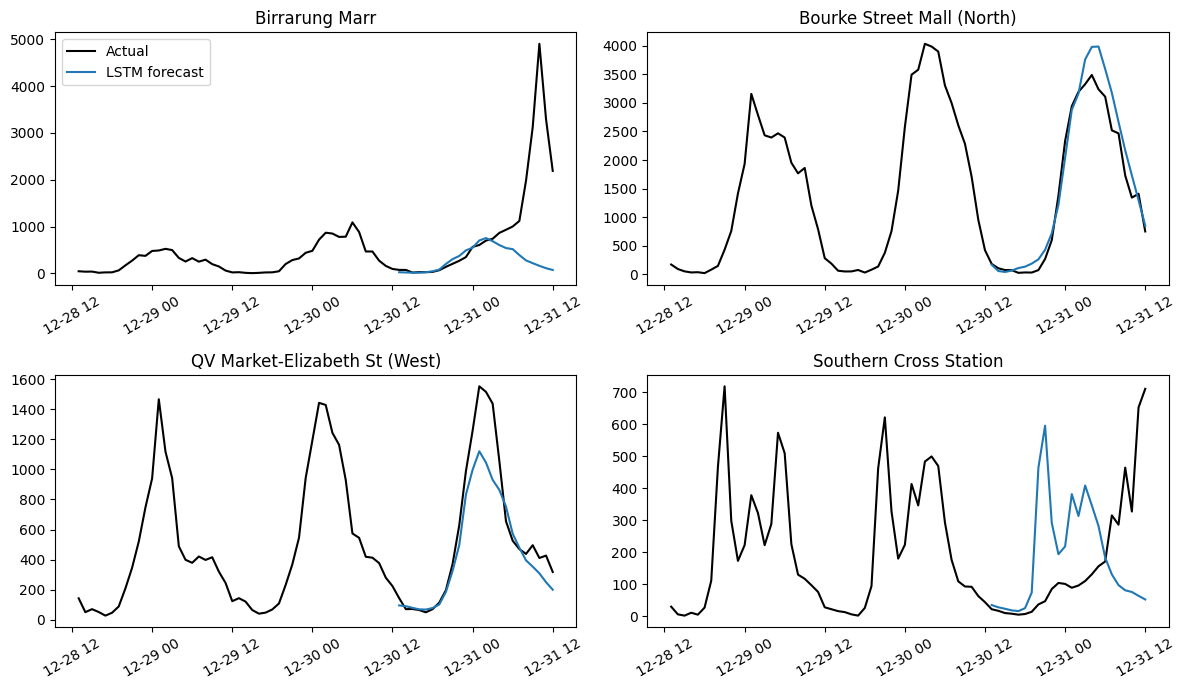

In [15]:
from neuralforecast.models import LSTM
from neuralforecast import NeuralForecast

# Your code
import urllib.request, pyreadr

# 1. Load the pedestrian data in long format (unique_id, ds, y)
url = "https://raw.githubusercontent.com/tidyverts/tsibble/main/data/pedestrian.rda"
urllib.request.urlretrieve(url, "pedestrian.rda")
ped = pyreadr.read_r("pedestrian.rda")["pedestrian"]
ped_df = ped.rename(columns={"Sensor": "unique_id", "Date_Time": "ds", "Count": "y"})[["unique_id", "ds", "y"]]

# 2. Keep December 2016 (avoids a month-long sensor outage) and fill the few missing hours
ped_df = ped_df[ped_df["ds"] >= "2016-12-01"]
ped_df = (ped_df.set_index("ds").groupby("unique_id")["y"]
                .apply(lambda s: s.asfreq("h").interpolate())
                .reset_index())

# 3. Hold out the last 24 hours of each sensor to check the forecast
train = ped_df.groupby("unique_id").head(-24)
test = ped_df.groupby("unique_id").tail(24)

# 4. One global LSTM for all sensors: 1 week of history -> next 24 hours
nf = NeuralForecast(models=[LSTM(h=24, input_size=168, max_steps=300,
                                 scaler_type="robust", random_seed=1)], freq="h")
nf.fit(df=train)
fcst = nf.predict()

# 5. Accuracy (MAE) per sensor
res = test.merge(fcst, on=["unique_id", "ds"])
print((res["y"] - res["LSTM"]).abs().groupby(res["unique_id"]).mean().round(1))

# 6. Plot the last 3 days plus the 24-hour forecast for each sensor
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (uid, g) in zip(axes.flat, ped_df.groupby("unique_id")):
    f = fcst[fcst["unique_id"] == uid]
    ax.plot(g["ds"].tail(72), g["y"].tail(72), color="black", label="Actual")
    ax.plot(f["ds"], f["LSTM"], color="tab:blue", label="LSTM forecast")
    ax.set_title(uid)
    ax.tick_params(axis="x", rotation=30)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

### Exercise 1.6: Conceptual — Hidden Layers
Explain the role of "hidden layers" in a Multilayer Perceptron (MLP). How does increasing the number of layers affect model capacity and the risk of overfitting?

In [16]:
"""
A multilayer perceptron, or MLP, passes inputs through one or, typically, several "hidden layers" before going through the output. These hidden layers create a
weighted combination of the previous layer's outputs combined with a nonlinear activation function, such as ReLU, to continuously distinguish and learn features.
In doing so, it surpasses a linear regression, learning more features of a given input (slope, seasonal patterns, etc.) through each new layer it passes through.
Without such, MLP is effectively a linear autoregression. That being said, the risk of overfitting can be severe: though the hidden layers greatly enrich the
network, noise can easily be increased in importance and rolled into the model's learning, which causes a gradually compounding error. This is especially bad
for our purposes in forecasting, as with typically smaller data sets, this snowballs out of control incredibly quickly.
"""

'\nA multilayer perceptron, or MLP, passes inputs through one or, typically, several "hidden layers" before going through the output. These hidden layers create a \nweighted combination of the previous layer\'s outputs combined with a nonlinear activation function, such as ReLU, to continuously distinguish and learn features.\nIn doing so, it surpasses a linear regression, learning more features of a given input (slope, seasonal patterns, etc.) through each new layer it passes through.\nWithout such, MLP is effectively a linear autoregression. That being said, the risk of overfitting can be severe: though the hidden layers greatly enrich the \nnetwork, noise can easily be increased in importance and rolled into the model\'s learning, which causes a gradually compounding error. This is especially bad\nfor our purposes in forecasting, as with typically smaller data sets, this snowballs out of control incredibly quickly. \n'

## Part 2: Zero-Shot Foundation Models
Unlike NHITS, which you just trained from scratch on your own panel, **time series foundation models** are pretrained on millions of series and can forecast new data with **no fitting step at all** — you just call `.forecast()`. Complete Exercise 2.1 (TimeGPT) **or** Exercise 2.2 (Chronos) — do both for extra credit.

### Exercise 2.1: TimeGPT (Nixtla)
`TimeGPT` is a hosted foundation model from Nixtla. It requires a free API key from [dashboard.nixtla.io](https://dashboard.nixtla.io) (sign up with a school or personal email).

In [21]:
from nixtla import NixtlaClient

nixtla_client = NixtlaClient(api_key="nixak-d1a804cad8166bcf2d142ed34106ee55950ff32f45a67841b22a3166dcc34242b8e41e0e65a62b59")

# Reuse the same long-format DataFrame (unique_id, ds, y) from Part 1
t0 = time.perf_counter()
fcst_df = nixtla_client.forecast(
    df=df,
    h=horizon,
    time_col="ds",
    target_col="y",
    id_col="unique_id",
    freq="M"  # match your data's frequency
)
fcst_df["ds"] = pd.to_datetime(fcst_df["ds"]).dt.to_period("M").dt.to_timestamp()
timegpt_secs = time.perf_counter() - t0

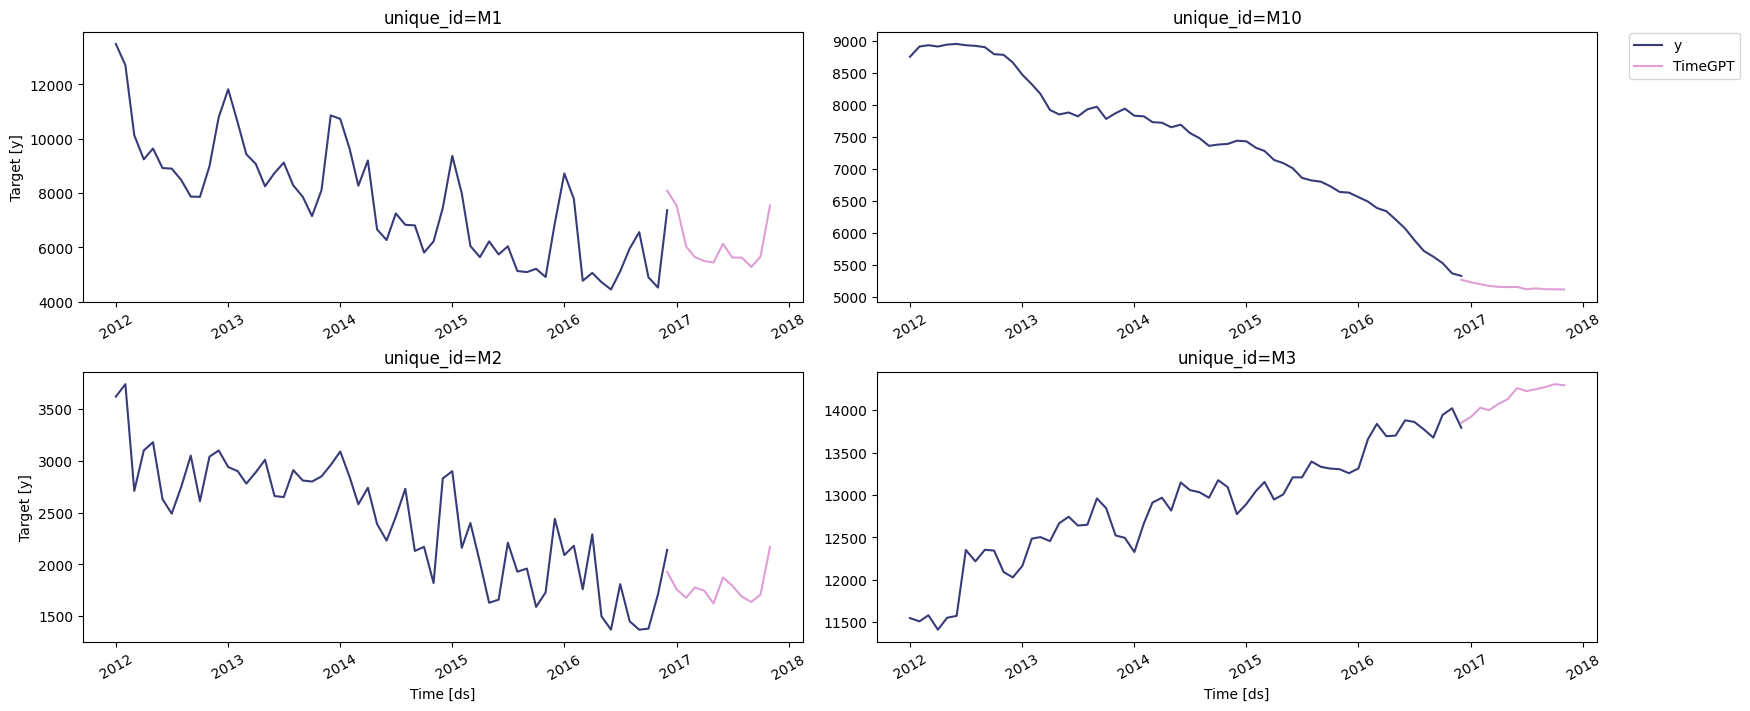

metric,mae,rmse,smape,mase
TimeGPT,125.670,125.670,0.013,0.292
NHITS,664.316,664.316,0.072,1.880
SeasonalNaive,464.500,464.500,0.050,1.547


TimeGPT: 17.7 s (no training)  vs  NHITS: 7.3 s (training + prediction)


In [22]:
# 2. Plot forecast against the actual holdout values
plot_df = df[df["ds"] > TRAIN_END - pd.DateOffset(months=48)]
display(nixtla_client.plot(plot_df, fcst_df, time_col="ds", target_col="y", unique_ids=df["unique_id"].unique()[:4].tolist()))

# 3. Compare to the Seasonal Naive benchmark (and NHITS) on the same series/horizon
tg = fcst_df.merge(stat_fcst[["unique_id", "ds", "SeasonalNaive"]], on=["unique_id", "ds"]).merge(nhits_fcst, on=["unique_id", "ds"])
display(score(tg, test_df, train_df, ["TimeGPT", "NHITS", "SeasonalNaive"], season=12))

# 4. Timing
print(f"TimeGPT: {timegpt_secs:.1f} s (no training)  vs  NHITS: {nhits_total_secs:.1f} s (training + prediction)")

In [19]:
# ANALYSIS
# In this run, our zero-shot model did beat out the SeasonalNaive benchmark! With a MAE of 125.670 vs SeasonalNaive's 464.500, we successfully beat the naive benchmark.
# Both significantly outperform NHITS as well, with a lousy MAE of 664.316. Additionally, TimeGPT took significantly longer to run (17.7 seconds vs 7.3) than NHITS.
# This is likely due to the time for the API to be called and respond - given that our model needs no training, on a larger data set where it would take longer for NHITS
# to run, we would likely see it vastly outclassed.

1. Generate a forecast for the **same series and horizon** you used for NHITS in Exercise 1.2 (or, if you have Nixtla token access, use the `AirPassengers` dataset).
2. Plot the TimeGPT forecast against the actual holdout values using `nixtla_client.plot(...)`.
3. Compute a **Seasonal Naive** benchmark forecast for the same series/horizon and compare its error (e.g., MAE) against TimeGPT's. Did the zero-shot model beat the naive benchmark?
4. Note how long the forecast took to generate compared to training NHITS. What did you *not* have to do that you did for the global model?

### Exercise 2.2: Chronos (Amazon, fully local)
If you'd rather not create an API account, use **Chronos**, an open-source foundation model you can run locally with no key required.

In [20]:
import torch
import pandas as pd
from chronos import BaseChronosPipeline

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32,
)

# Chronos forecasts one series at a time from a 1D context tensor
context = torch.tensor(df.loc[df["unique_id"] == "series_1", "y"].values)
quantiles, mean = pipeline.predict_quantiles(
    context,
    prediction_length=horizon,
    quantile_levels=[0.1, 0.5, 0.9],
)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

1. Run Chronos on **one series** from your panel and plot the median forecast (`mean`) alongside the 10th/90th percentile band.
2. Loop over at least 3 series and record each model's error (e.g., MAE) in a small comparison table.
3. Chronos ships in multiple sizes (`tiny`, `mini`, `small`, `base`, `large`). Try swapping in a different size — does accuracy change? Does speed?

### Exercise 2.3: Conceptual — Zero-Shot vs. Transfer Learning
Describe the "zero-shot" inference capability of foundation models like TimeGPT. How does it differ from the "transfer learning" you discussed for NHITS in Exercise 1.3?

In [23]:
"""
Zero-shot inference is the ability of a model to, on a data set it has not seen or trained on, forecast with no gradient steps or fitting. Models like TimeGPT are
pre-trained on many, many massive sets of data, with the aim of then being able to adapt to new sets without need for prior training. In this sense, the data provided
is simply context that it is trained on, while a model like NHITS is trained specifically and solely on the data series provided. Thus, there is no transfer
learning, as all real learning has already been done long before it reached our data.
"""

'\nZero-shot inference is the ability of a model to, on a data set it has not seen or trained on, forecast with no gradient steps or fitting. Models like TimeGPT are\npre-trained on many, many massive sets of data, with the aim of then being able to adapt to new sets without need for prior training. In this sense, the data provided\nis simply context that it is trained on, while a model like NHITS is trained specifically and solely on the data series provided. Thus, there is no transfer\nlearning, as all real learning has already been done long before it reached our data.\n'

### Exercise 2.4: Synthesis — Trained vs. Zero-Shot
Using your results from Part 1 and Part 2, write a short (3-5 sentence) comparison addressing:

1. **Accuracy**: Which approach (NHITS, TimeGPT/Chronos, or ARIMA) performed best on your data, and why might that be?
2. **Cost of entry**: How much data, compute, and time did each approach require *before* it produced its first forecast?
3. **When to use which**: Describe a real business scenario where a zero-shot foundation model would be preferable to training a custom global model, and one where it wouldn't. What are the potential advantages of a foundation model (like Chronos or TimesFM) specifically when your dataset is *too small* to train a local or global model well?

In [ ]:
"""
Of all of the approaches, TimeGPT has done best. Though AutoMLP did well on the local scale, TimeGPT has done the best overall. With a significantly lower error compared
to AutoMLP's middling improvement, as well as a slightly longer though still quite acceptable run time than the naive model, TimeGPT was the most efficient for the
greatest effect. As a global model, TimeGPT performs significantly better on the types of data sets we've been using, and with a strong variety of backgrounds
it forecasts our data better than local models can for significantly less cost. NHITS and ARIMA both eat a significant amount of time training before beginning to forecast,
which is unnecessary with small series such as these. Zero-shot foundation models are most effective with these small series, where there's not much work to be done and not
much need for complexity; a custom global model is great for massive data sets with many long series, where accuracy is more important than a generalized result. Foundation
models avoid the overfitting by simply not fitting where fitting is not needed on tiny datasets, and can be tuned as needed instead.
"""

## Grading Rubric
- **Correctness (35%)**: Does the DL pipeline (NHITS/MLP/LSTM) and at least one zero-shot model (TimeGPT or Chronos) run without errors?
- **Code Quality (25%)**: Proper data formatting (`unique_id`), reused consistently across models.
- **Zero-Shot Exercise (20%)**: Completed forecast + plot for TimeGPT or Chronos, with a basic accuracy comparison (including the Seasonal Naive benchmark).
- **Analysis (20%)**: Understanding of Local vs. Global modeling, and Trained vs. Zero-Shot tradeoffs (Exercises 2.3-2.4).